<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">
<h1 style="font-family:verdana; font-size:24px">
<br>
<center>Pengujian dan Analisis Feedforward Neural Network</center></h1>
<h2 style="font-family:verdana; font-size:16px"><center>Tugas Besar 1 IF3270 Pembelajaran Mesin 2025/2026 | Dataset: global_student_placement_and_salary</center></h2>

<br>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## **Tim AlphaAziz**

- Leonard Arif Sutiono / 1823120
- Harfhan Ikhtiar Ahmad Ridzky / 18223123
- Izhar Alif Akbar / 18223129

<br>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Daftar Isi

1. [**Pendahuluan**](#1)
2. [**Inisialisasi**](#2)
3. [**Pemuatan Data dan Preprocessing**](#3)
4. [**Helper Eksperimen**](#4)
5. [**Analisis Width dan Depth**](#5)
6. [**Analisis Fungsi Aktivasi Hidden Layer**](#6)
7. [**Analisis Learning Rate**](#7)
8. [**Analisis Regularisasi**](#8)
9. [**Perbandingan dengan sklearn MLP**](#9)
10. [**Ringkasan Akhir**](#10)

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Pendahuluan <a name="1"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Notebook ini digunakan untuk menguji implementasi Feedforward Neural Network (FFNN) dari folder `src/model` pada dataset `global_student_placement_and_salary`. Seluruh pengujian mengikuti ketentuan spesifikasi tugas besar: analisis pengaruh width, depth, fungsi aktivasi hidden layer, learning rate, regularisasi, serta perbandingan dengan `sklearn MLP`.

Agar notebook tetap rapi dan mudah dijalankan ulang, alur kerja dibagi menjadi empat tahap utama: persiapan data, helper eksperimen, eksperimen inti, dan ringkasan akhir. Untuk menjaga visual tetap konsisten, bagian judul, pembatas section, tabel ringkas, dan gaya plot mengikuti pola penyajian pada notebook referensi.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Inisialisasi <a name="2"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Instalasi dan Impor Pustaka

Sel ini menyiapkan dependensi utama yang dipakai notebook. Jika environment Anda sudah memiliki seluruh pustaka tersebut, sel instalasi dapat dilewati.

In [6]:
%pip install numpy pandas matplotlib seaborn scikit-learn tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore', category=ConvergenceWarning)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
DATA_PATH = SRC_DIR / 'data' / 'datasetml_2026.csv'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from model.model import FFNN, Layer

SEED = 42
EPOCHS = 30
BATCH_SIZE = 32
BASE_LEARNING_RATE = 0.01
BASE_WIDTH = [32, 16]
BASE_ACTIVATIONS = ['relu', 'relu']

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'grid.color': '#E7E4DF'
})

BACKGROUND = 'white'
COLORS = ['#8E7B6B', '#C97B63', '#4C6A92', '#6F9E6E', '#A663CC']

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)


def style_fig(fig, axes=None):
    fig.patch.set_facecolor(BACKGROUND)
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(1.5)
    if axes is not None:
        for ax in np.ravel(axes):
            if hasattr(ax, 'set_facecolor'):
                ax.set_facecolor(BACKGROUND)
    fig.tight_layout()


set_seed()
print(f'Project root  : {PROJECT_ROOT}')
print(f'Data path     : {DATA_PATH}')
print(f'Seed eksperimen: {SEED}')

Project root  : c:\Izhar\STI\Semester 6\Machine Learning\TubesML
Data path     : c:\Izhar\STI\Semester 6\Machine Learning\TubesML\src\data\datasetml_2026.csv
Seed eksperimen: 42


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Pemuatan Data dan Preprocessing <a name="3"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Dataset berisi fitur numerik dan kategorikal dengan target biner `placement_status`. Pada notebook ini, target diubah menjadi label `1 = Placed` dan `0 = Not Placed`, lalu data dibagi menjadi train, validation, dan test agar seluruh eksperimen dibandingkan pada split yang sama.

In [8]:
df = pd.read_csv(DATA_PATH)

target_mapping = {'Placed': 1, 'Not Placed': 0}
df['placement_status_label'] = df['placement_status'].map(target_mapping)

numeric_features = [
    'cgpa',
    'backlogs',
    'internship_count',
    'aptitude_score',
    'communication_score',
    'internship_quality_score'
]

categorical_features = [
    'college_tier',
    'country',
    'university_ranking_band',
    'specialization',
    'industry'
]

print(f'Jumlah baris   : {len(df):,}')
print(f'Jumlah kolom   : {df.shape[1]}')
print('Distribusi target:')
display(df['placement_status'].value_counts().rename_axis('kelas').to_frame('jumlah'))

print('Contoh data:')
display(df.head())

ringkasan_fitur = pd.DataFrame({
    'tipe_fitur': ['numerik', 'kategorikal', 'target'],
    'daftar_kolom': [
        ', '.join(numeric_features),
        ', '.join(categorical_features),
        'placement_status_label'
    ]
})

display(ringkasan_fitur)

Jumlah baris   : 10,000
Jumlah kolom   : 13
Distribusi target:


,jumlah
kelas,
Placed,6153
Not Placed,3847


Contoh data:


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status,placement_status_label
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed,1
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed,1
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed,1
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed,1
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed,1


,tipe_fitur,daftar_kolom
0,numerik,"cgpa, backlogs, internship_count, aptitude_sco..."
1,kategorikal,"college_tier, country, university_ranking_band..."
2,target,placement_status_label


In [9]:
X = df[numeric_features + categorical_features]
y = df['placement_status_label'].to_numpy().reshape(-1, 1)

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

X_train_df, X_val_df, y_train, y_val = train_test_split(
    X_train_df,
    y_train,
    test_size=0.25,
    random_state=SEED,
    stratify=y_train
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

X_train = preprocessor.fit_transform(X_train_df).astype(np.float64)
X_val = preprocessor.transform(X_val_df).astype(np.float64)
X_test = preprocessor.transform(X_test_df).astype(np.float64)

feature_names = preprocessor.get_feature_names_out()
input_dim = X_train.shape[1]

print(f'Ukuran train      : {X_train.shape}')
print(f'Ukuran validation : {X_val.shape}')
print(f'Ukuran test       : {X_test.shape}')
print(f'Jumlah fitur akhir: {input_dim}')

Ukuran train      : (6000, 28)
Ukuran validation : (2000, 28)
Ukuran test       : (2000, 28)
Jumlah fitur akhir: 28


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Helper Eksperimen <a name="4"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Bagian ini memusatkan fungsi pembangun model, training, evaluasi, serta visualisasi. Dengan helper yang konsisten, setiap eksperimen dapat ditulis singkat dan hasilnya mudah dibandingkan.

In [10]:
def build_ffnn(hidden_layers, hidden_activations, learning_rate=BASE_LEARNING_RATE,
               regularization_type=None, lam=0.0, init_method='uniform', init_kwargs=None):
    model = FFNN(loss_name='bce', regularization_type=regularization_type, lam=lam)
    previous_dim = input_dim

    for neurons, activation in zip(hidden_layers, hidden_activations):
        model.add_layer(Layer(previous_dim, neurons, activation))
        previous_dim = neurons

    model.add_layer(Layer(previous_dim, 1, 'sigmoid'))

    if init_kwargs is None:
        init_kwargs = {'lower_bound': -0.05, 'upper_bound': 0.05}

    model.initialize_weights(method=init_method, input_dim=input_dim, **init_kwargs)
    return model


def predict_proba_ffnn(model, X_data):
    return np.clip(model.forward(X_data).reshape(-1), 1e-7, 1 - 1e-7)


def predict_label_ffnn(model, X_data, threshold=0.5):
    return (predict_proba_ffnn(model, X_data) >= threshold).astype(int)


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    }


def to_metric_frame(results):
    rows = []
    for result in results:
        rows.append({
            'Eksperimen': result['name'],
            'Accuracy': result['metrics']['accuracy'],
            'Precision': result['metrics']['precision'],
            'Recall': result['metrics']['recall'],
            'F1': result['metrics']['f1']
        })
    return pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)


def get_layer_labels(model):
    labels = []
    for idx in range(len(model.layers)):
        if idx == len(model.layers) - 1:
            labels.append('Output')
        else:
            labels.append(f'Hidden {idx + 1}')
    return labels


def plot_loss_curves(results, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_axis = np.arange(1, len(results[0]['history']['train_loss']) + 1)

    for idx, result in enumerate(results):
        color = COLORS[idx % len(COLORS)]
        axes[0].plot(epochs_axis, result['history']['train_loss'], linewidth=2, color=color, label=result['name'])
        axes[1].plot(epochs_axis, result['history']['val_loss'], linewidth=2, color=color, label=result['name'])

    axes[0].set_title('Training Loss per Epoch')
    axes[1].set_title('Validation Loss per Epoch')

    for ax in axes:
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()

    fig.suptitle(title, fontsize=14)
    style_fig(fig, axes)
    plt.show()


def plot_parameter_overview(model, experiment_name):
    layer_labels = get_layer_labels(model)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for idx, label in enumerate(layer_labels):
        params = np.concatenate([model.layers[idx].W.flatten(), model.layers[idx].b.flatten()])
        grads = np.concatenate([model.layers[idx].dW.flatten(), model.layers[idx].db.flatten()])
        axes[0].hist(params, bins=30, alpha=0.45, label=label)
        axes[1].hist(grads, bins=30, alpha=0.45, label=label)

    axes[0].set_title('Distribusi Bobot + Bias (Gabungan)')
    axes[1].set_title('Distribusi Gradien Bobot + Bias (Gabungan)')
    axes[0].set_xlabel('Nilai')
    axes[1].set_xlabel('Nilai')
    axes[0].set_ylabel('Frekuensi')
    axes[1].set_ylabel('Frekuensi')
    axes[0].legend()
    axes[1].legend()
    fig.suptitle(f'Ringkasan Distribusi Parameter | {experiment_name}', fontsize=14)
    style_fig(fig, axes)
    plt.show()

    fig, axes = plt.subplots(len(model.layers), 2, figsize=(12, 4 * len(model.layers)))
    if len(model.layers) == 1:
        axes = np.array([axes])

    for idx, label in enumerate(layer_labels):
        params = np.concatenate([model.layers[idx].W.flatten(), model.layers[idx].b.flatten()])
        grads = np.concatenate([model.layers[idx].dW.flatten(), model.layers[idx].db.flatten()])

        axes[idx, 0].hist(params, bins=30, color='#4C6A92', alpha=0.8)
        axes[idx, 1].hist(grads, bins=30, color='#C97B63', alpha=0.8)
        axes[idx, 0].set_title(f'{label} | Bobot + Bias')
        axes[idx, 1].set_title(f'{label} | Gradien Bobot + Bias')
        axes[idx, 0].set_xlabel('Nilai')
        axes[idx, 1].set_xlabel('Nilai')
        axes[idx, 0].set_ylabel('Frekuensi')
        axes[idx, 1].set_ylabel('Frekuensi')

    fig.suptitle(f'Distribusi per Layer | {experiment_name}', fontsize=14, y=1.02)
    style_fig(fig, axes)
    plt.show()


def run_ffnn_experiment(name, hidden_layers, hidden_activations, learning_rate=BASE_LEARNING_RATE,
                        epochs=EPOCHS, batch_size=BATCH_SIZE, regularization_type=None,
                        lam=0.0, init_method='uniform', init_kwargs=None, verbose=0):
    set_seed()
    model = build_ffnn(
        hidden_layers=hidden_layers,
        hidden_activations=hidden_activations,
        learning_rate=learning_rate,
        regularization_type=regularization_type,
        lam=lam,
        init_method=init_method,
        init_kwargs=init_kwargs
    )

    model.fit(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        verbose=verbose
    )

    test_predictions = predict_label_ffnn(model, X_test)
    metrics = compute_metrics(y_test, test_predictions)

    return {
        'name': name,
        'model': model,
        'history': model.history,
        'metrics': metrics,
        'predictions': test_predictions,
        'hidden_layers': hidden_layers,
        'hidden_activations': hidden_activations,
        'learning_rate': learning_rate,
        'regularization_type': regularization_type,
        'lam': lam
    }


def run_sklearn_mlp(name, hidden_layers, activation='relu', learning_rate=BASE_LEARNING_RATE,
                    epochs=EPOCHS, batch_size=BATCH_SIZE):
    activation_map = {
        'relu': 'relu',
        'sigmoid': 'logistic',
        'tanh': 'tanh',
        'linear': 'identity'
    }

    clf = MLPClassifier(
        hidden_layer_sizes=tuple(hidden_layers),
        activation=activation_map[activation],
        solver='sgd',
        learning_rate_init=learning_rate,
        batch_size=batch_size,
        max_iter=epochs,
        random_state=SEED,
        shuffle=True,
        momentum=0.0,
        nesterovs_momentum=False
    )

    clf.fit(X_train, y_train.ravel())
    predictions = clf.predict(X_test)
    metrics = compute_metrics(y_test, predictions)

    return {
        'name': name,
        'model': clf,
        'metrics': metrics,
        'predictions': predictions
    }

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Analisis Width dan Depth <a name="5"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Pada eksperimen pertama, depth dan width dianalisis secara terpisah. Untuk eksperimen width, jumlah hidden layer dibuat tetap sebanyak dua layer. Untuk eksperimen depth, jumlah neuron setiap hidden layer dibuat tetap agar perubahan performa lebih mudah dikaitkan dengan banyaknya layer.

Hasil akhir prediksi untuk variasi width:


,Eksperimen,Accuracy,Precision,Recall,F1
0,Width 32-16,0.7510,0.785214,0.819659,0.802067
1,Width 64-32,0.7495,0.781636,0.822908,0.801741
2,Width 16-8,0.6155,0.615500,1.000000,0.761993


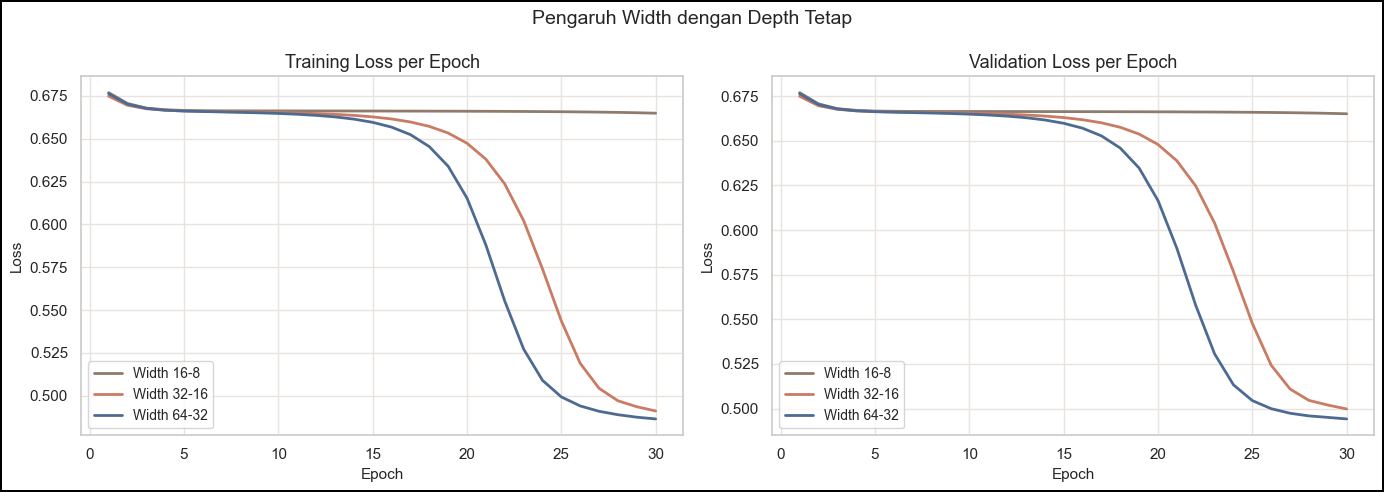

In [11]:
width_configs = [
    ('Width 16-8', [16, 8], ['relu', 'relu']),
    ('Width 32-16', [32, 16], ['relu', 'relu']),
    ('Width 64-32', [64, 32], ['relu', 'relu'])
]

width_results = []
for name, hidden_layers, hidden_activations in width_configs:
    width_results.append(
        run_ffnn_experiment(
            name=name,
            hidden_layers=hidden_layers,
            hidden_activations=hidden_activations,
            learning_rate=BASE_LEARNING_RATE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )
    )

print('Hasil akhir prediksi untuk variasi width:')
display(to_metric_frame(width_results))
plot_loss_curves(width_results, 'Pengaruh Width dengan Depth Tetap')

Hasil akhir prediksi untuk variasi depth:


,Eksperimen,Accuracy,Precision,Recall,F1
0,Depth 2 hidden layer,0.7535,0.780395,0.834281,0.806439
1,Depth 1 hidden layer,0.7520,0.778198,0.835093,0.805643
2,Depth 3 hidden layer,0.6155,0.615500,1.000000,0.761993


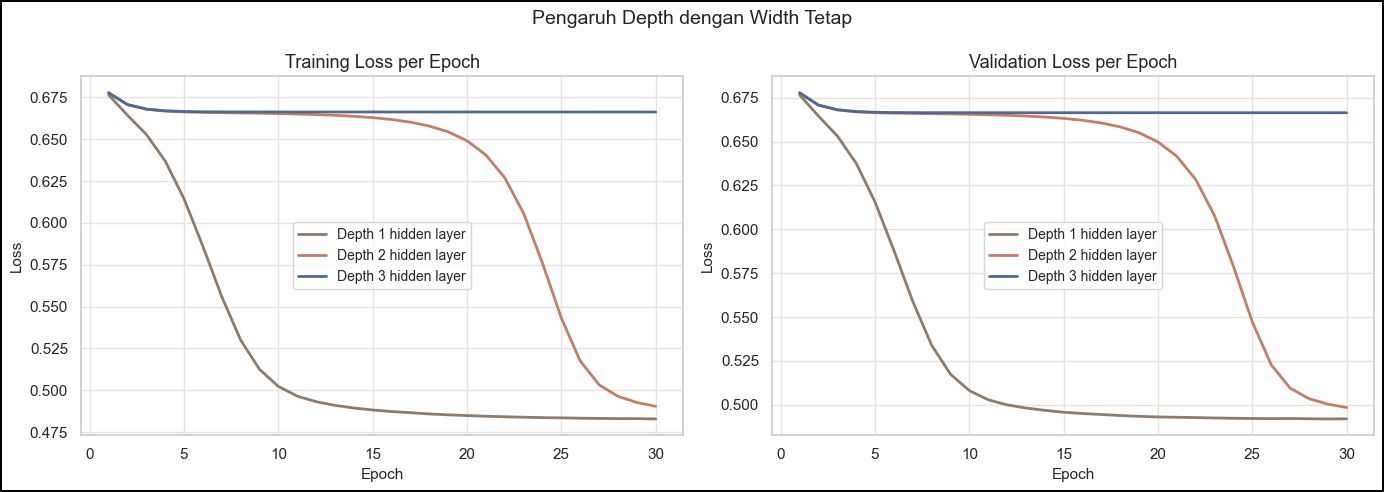

In [12]:
depth_configs = [
    ('Depth 1 hidden layer', [32], ['relu']),
    ('Depth 2 hidden layer', [32, 32], ['relu', 'relu']),
    ('Depth 3 hidden layer', [32, 32, 32], ['relu', 'relu', 'relu'])
]

depth_results = []
for name, hidden_layers, hidden_activations in depth_configs:
    depth_results.append(
        run_ffnn_experiment(
            name=name,
            hidden_layers=hidden_layers,
            hidden_activations=hidden_activations,
            learning_rate=BASE_LEARNING_RATE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )
    )

print('Hasil akhir prediksi untuk variasi depth:')
display(to_metric_frame(depth_results))
plot_loss_curves(depth_results, 'Pengaruh Depth dengan Width Tetap')

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Analisis Fungsi Aktivasi Hidden Layer <a name="6"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Base arsitektur yang dipakai pada bagian ini adalah `input -> 32 -> 16 -> 1`, dengan layer pengujian berada pada hidden layer pertama. Aktivasi hidden layer kedua dijaga tetap `relu`, sedangkan hidden layer pertama diuji dengan seluruh fungsi aktivasi yang diimplementasikan kecuali `softmax`.

Hasil akhir prediksi untuk variasi aktivasi hidden layer:


,Eksperimen,Accuracy,Precision,Recall,F1
0,Hidden 1 = relu,0.7510,0.785214,0.819659,0.802067
1,Hidden 1 = linear,0.7505,0.784603,0.819659,0.801748
2,Hidden 1 = tanh,0.7485,0.783489,0.817222,0.800000
3,Hidden 1 = sigmoid,0.6155,0.615500,1.000000,0.761993


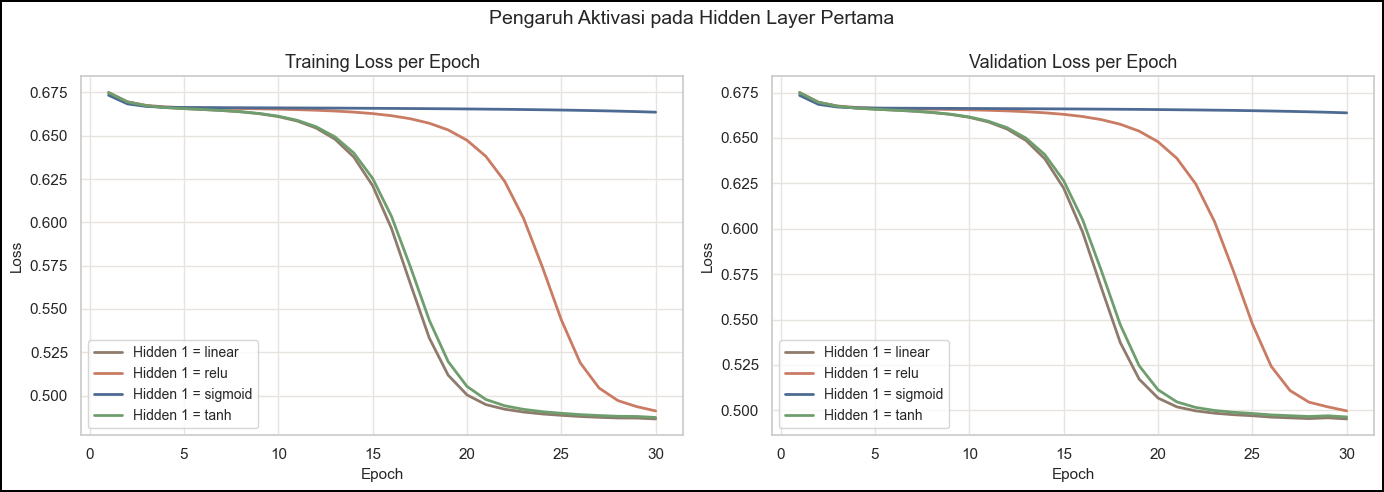

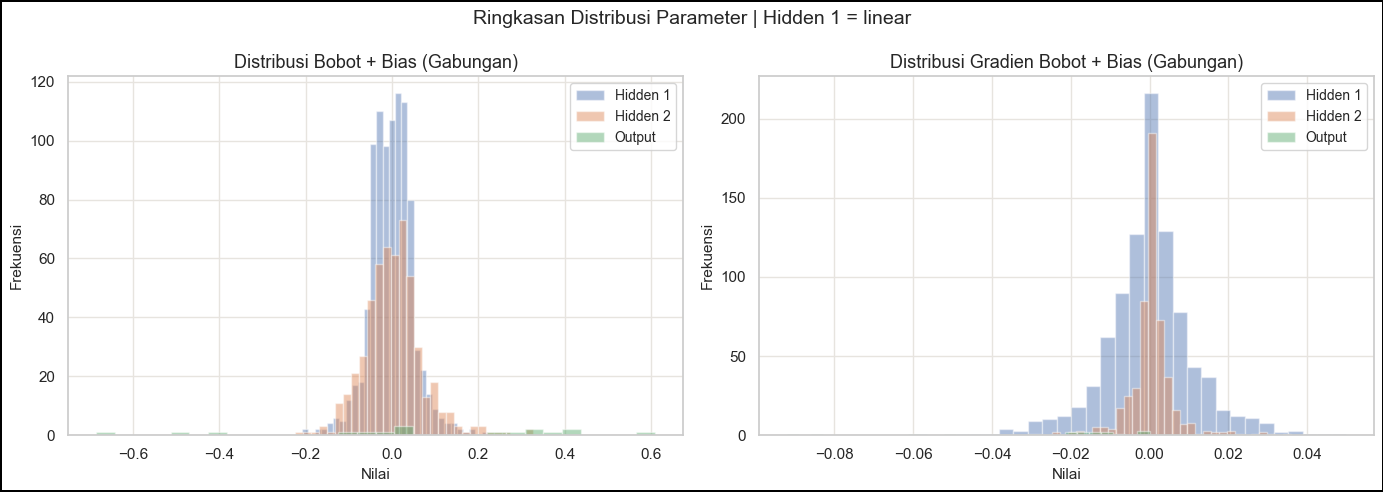

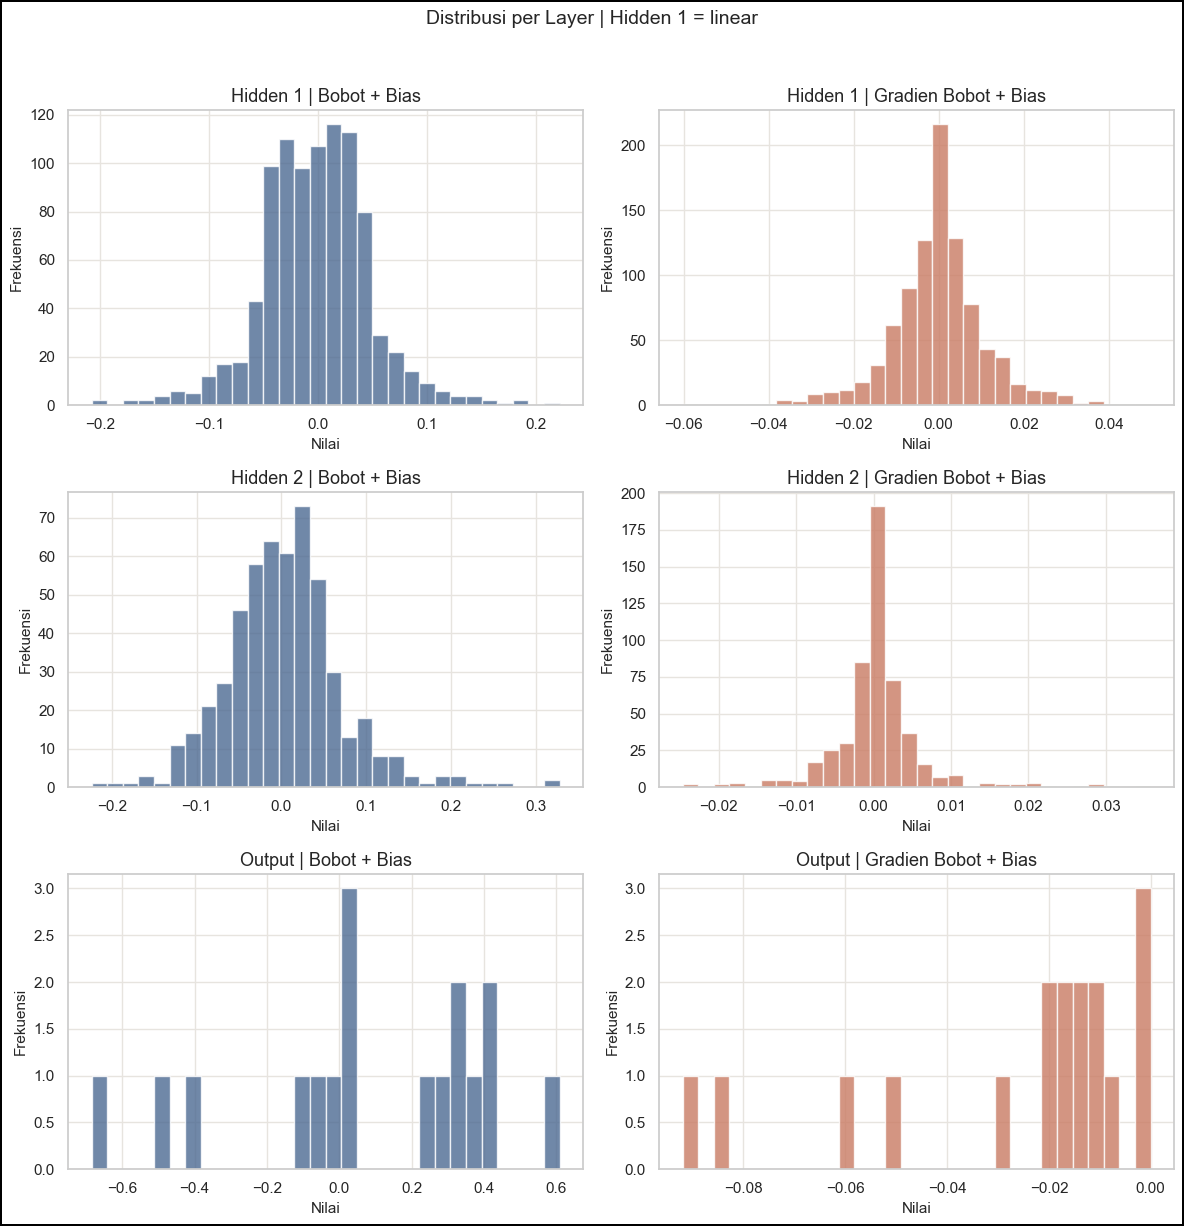

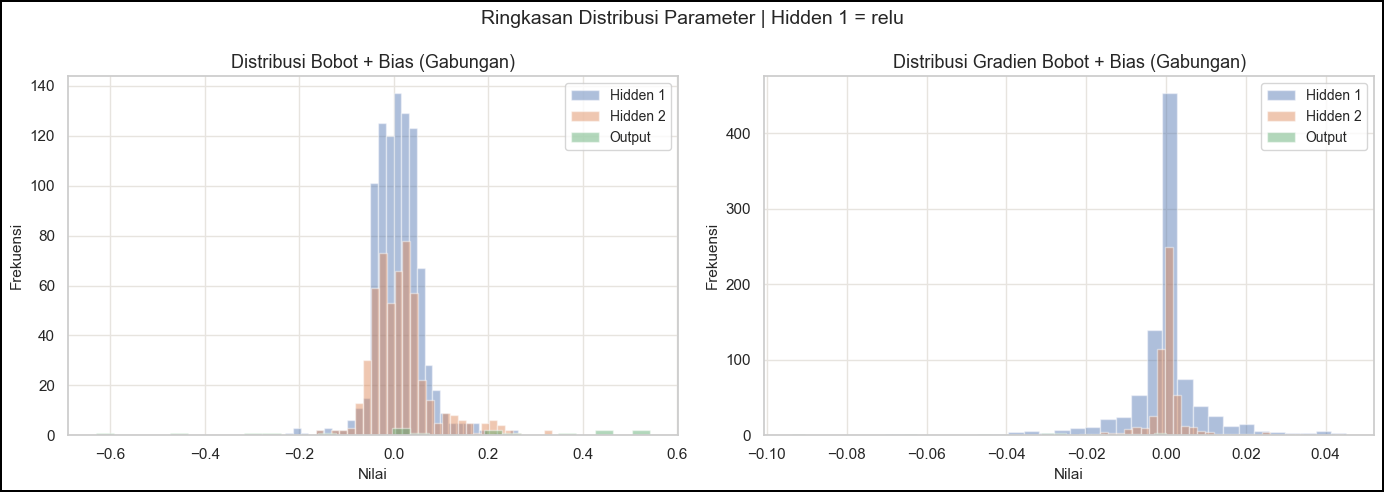

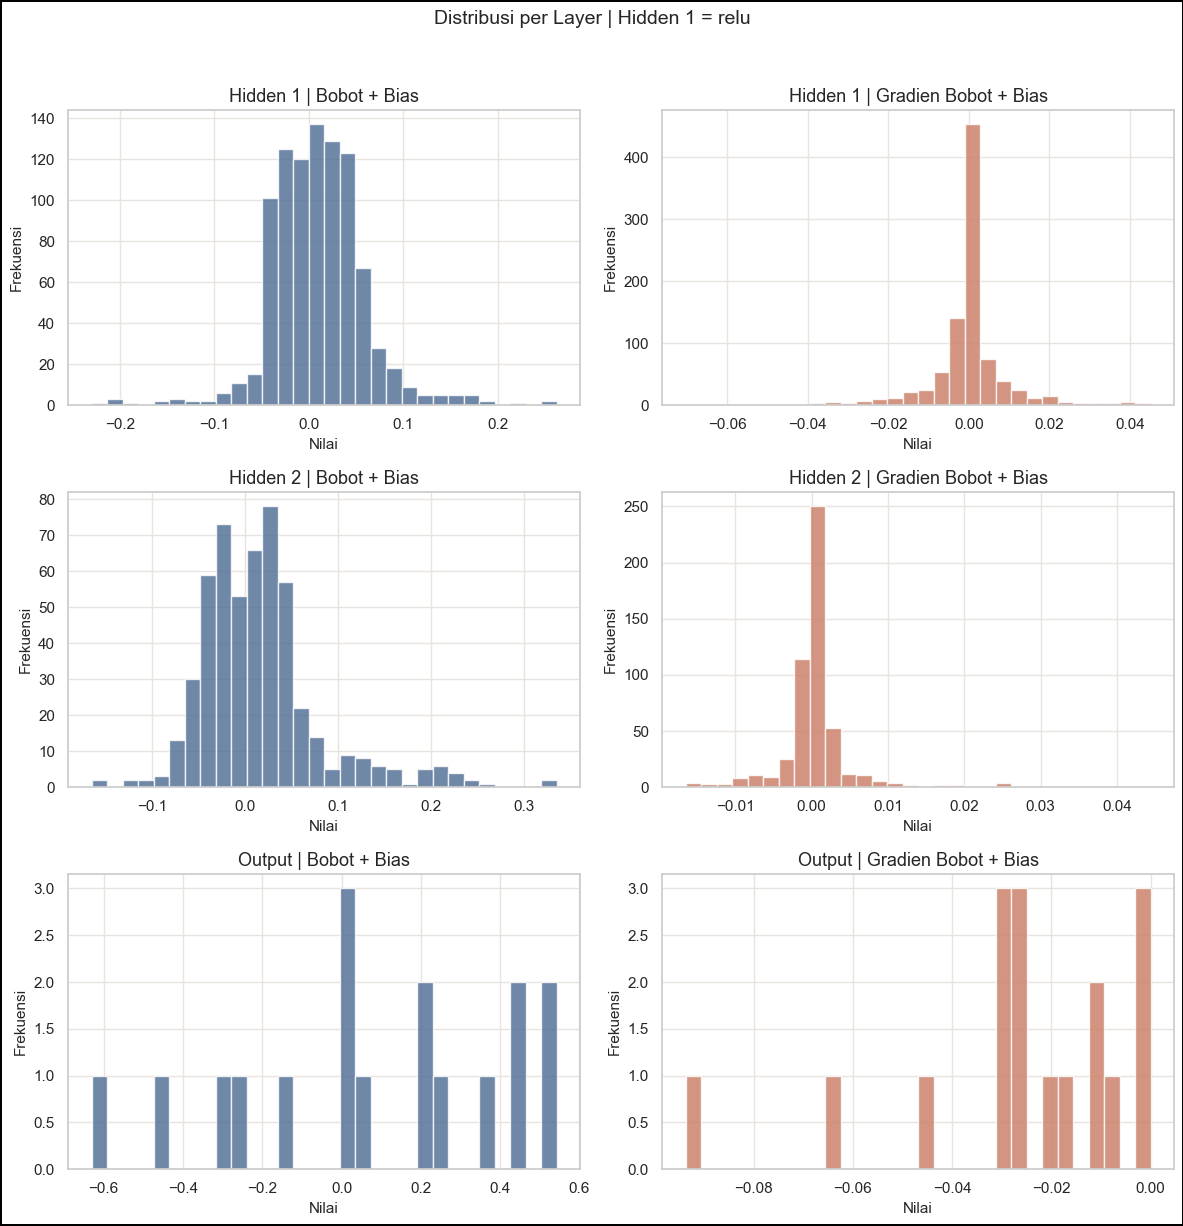

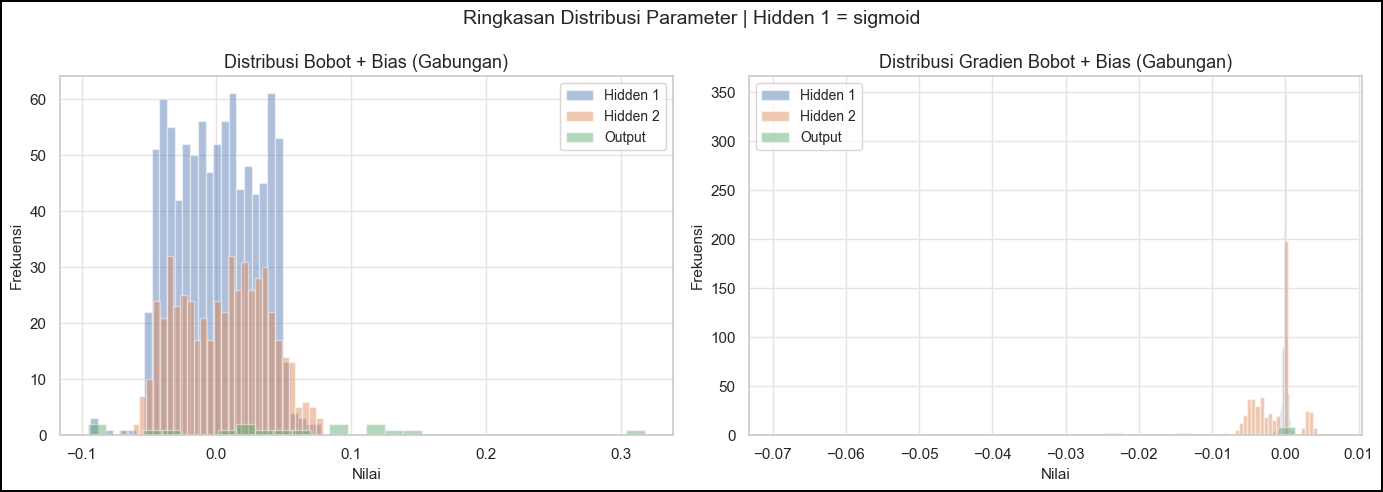

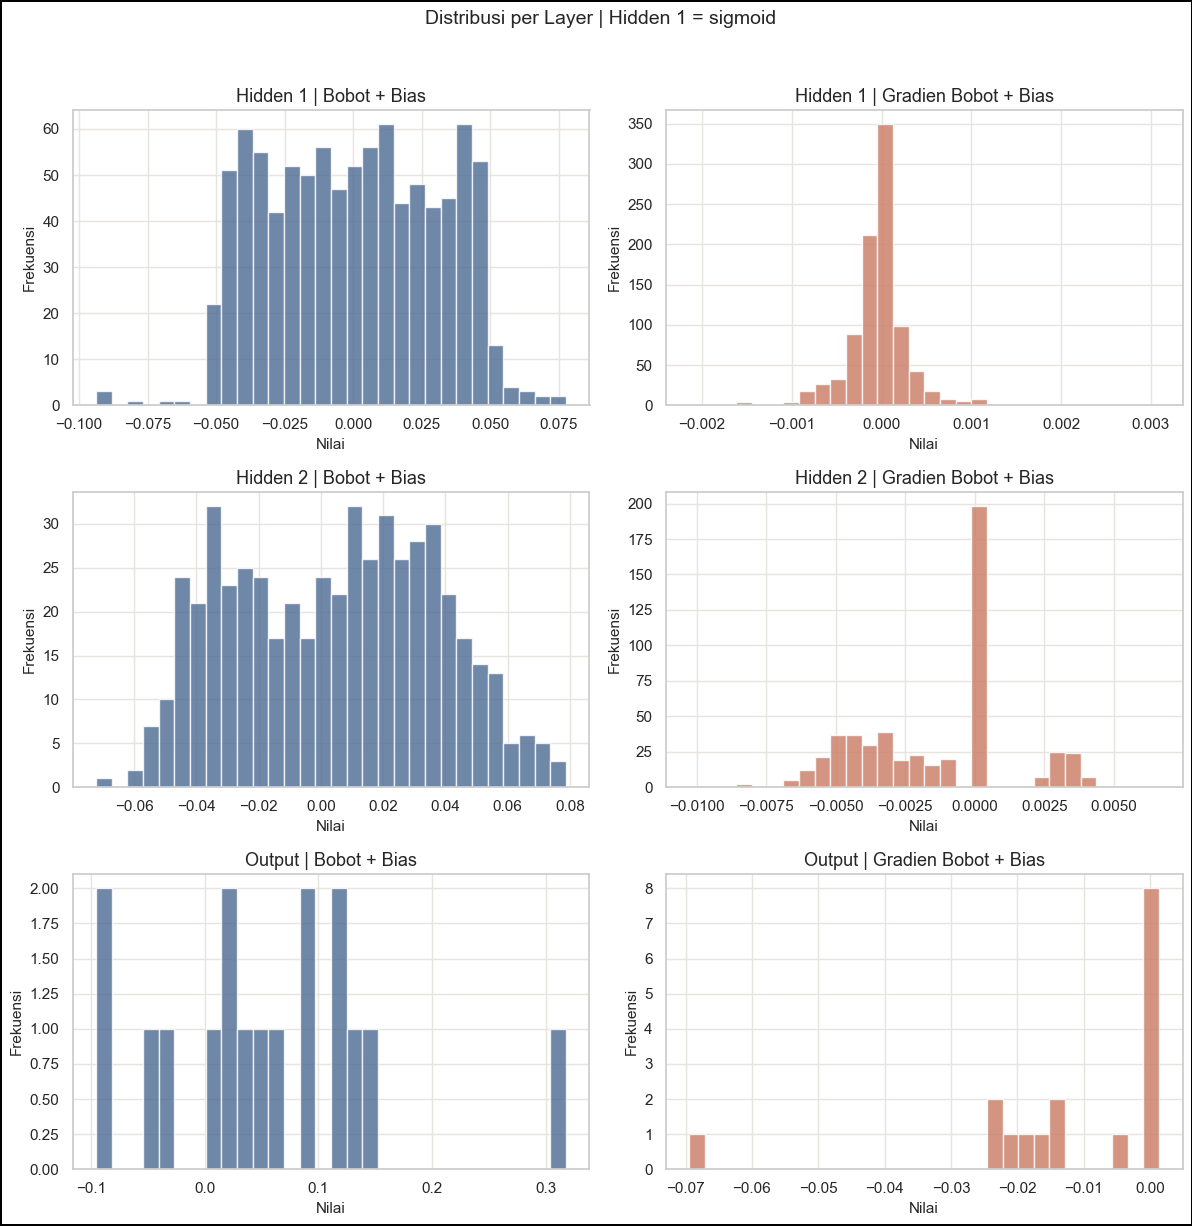

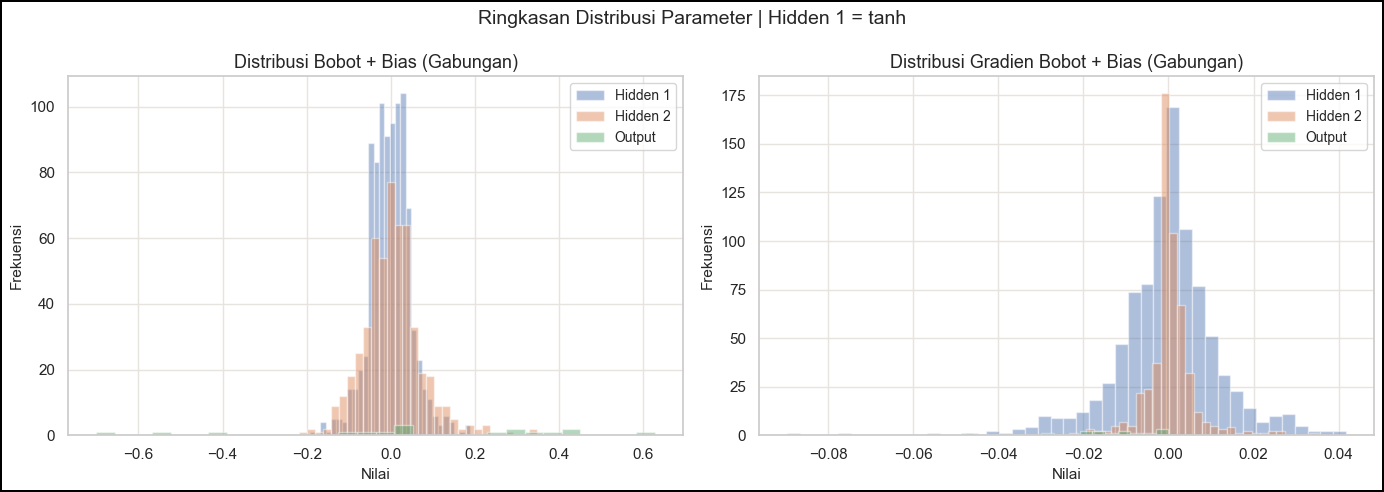

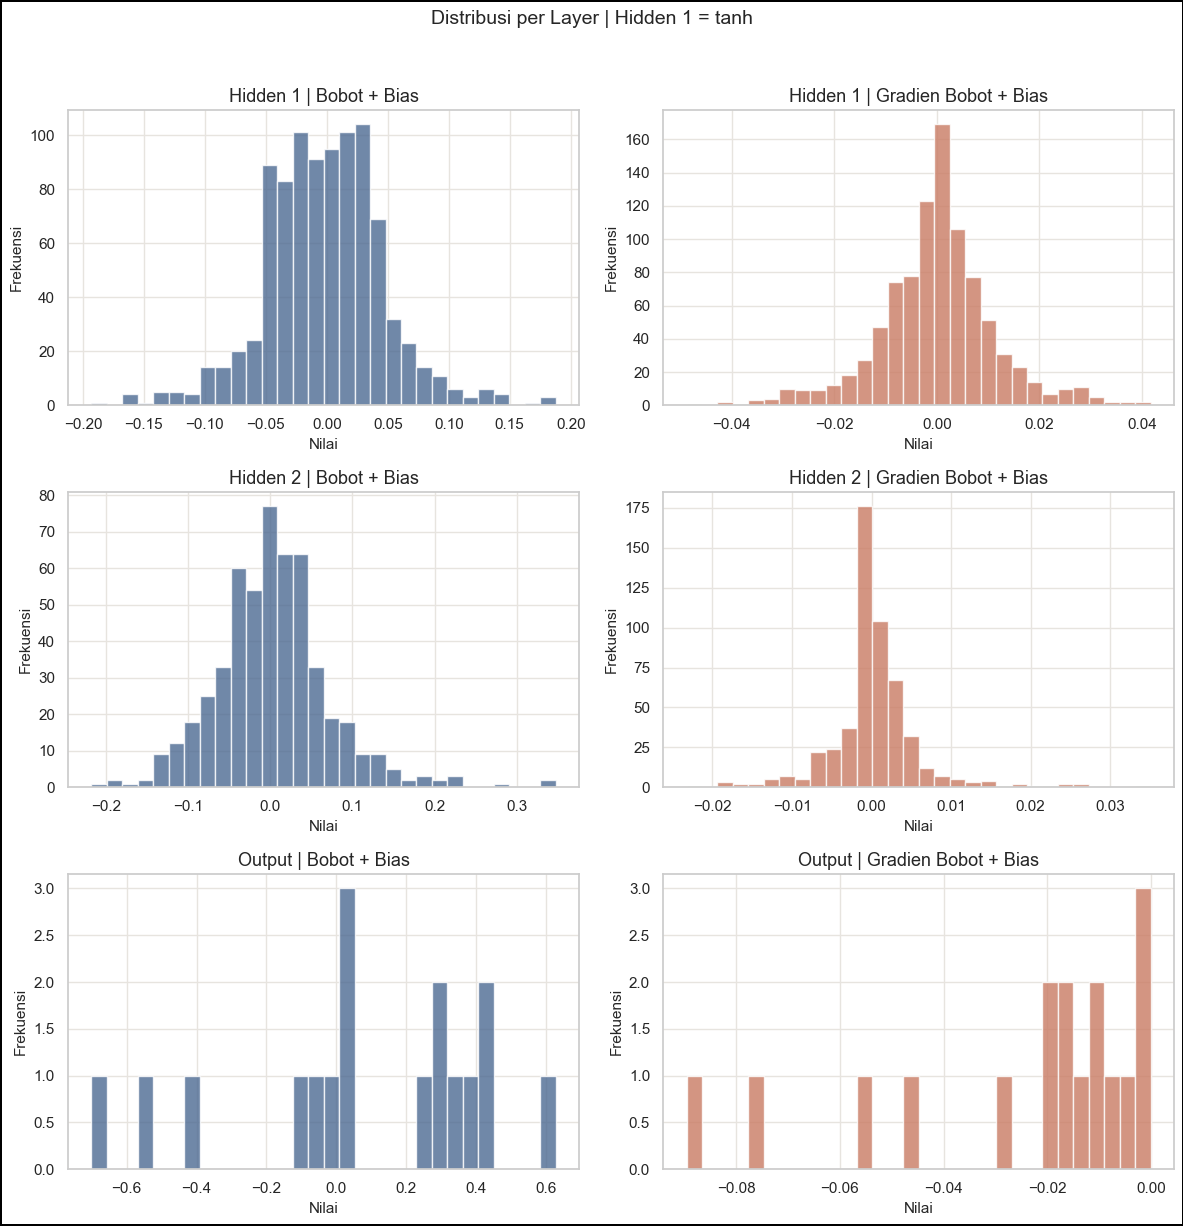

In [13]:
activation_candidates = ['linear', 'relu', 'sigmoid', 'tanh']
activation_results = []

for activation_name in activation_candidates:
    activation_results.append(
        run_ffnn_experiment(
            name=f'Hidden 1 = {activation_name}',
            hidden_layers=BASE_WIDTH,
            hidden_activations=[activation_name, 'relu'],
            learning_rate=BASE_LEARNING_RATE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )
    )

print('Hasil akhir prediksi untuk variasi aktivasi hidden layer:')
display(to_metric_frame(activation_results))
plot_loss_curves(activation_results, 'Pengaruh Aktivasi pada Hidden Layer Pertama')

for result in activation_results:
    plot_parameter_overview(result['model'], result['name'])

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Analisis Learning Rate <a name="7"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Learning rate diuji pada tiga skenario agar terlihat perbedaan kecepatan konvergensi, stabilitas training, dan hasil prediksi akhirnya. Arsitektur model pada bagian ini dijaga tetap sama dengan base arsitektur.

Hasil akhir prediksi untuk variasi learning rate:


,Eksperimen,Accuracy,Precision,Recall,F1
0,Learning rate = 0.01,0.7510,0.785214,0.819659,0.802067
1,Learning rate = 0.05,0.7495,0.786950,0.813160,0.799840
2,Learning rate = 0.001,0.6155,0.615500,1.000000,0.761993


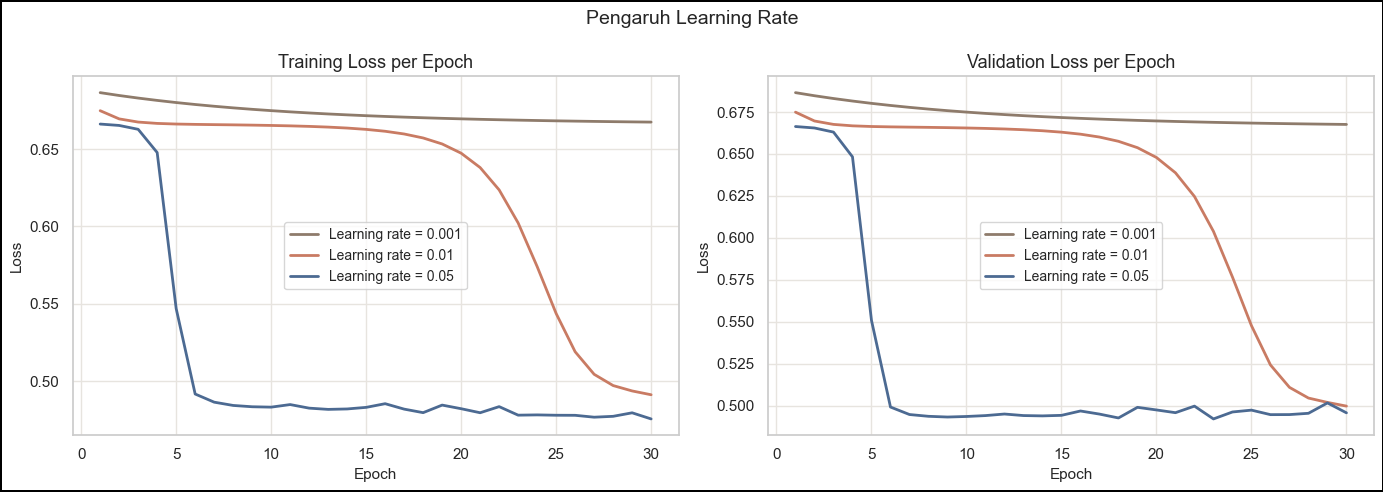

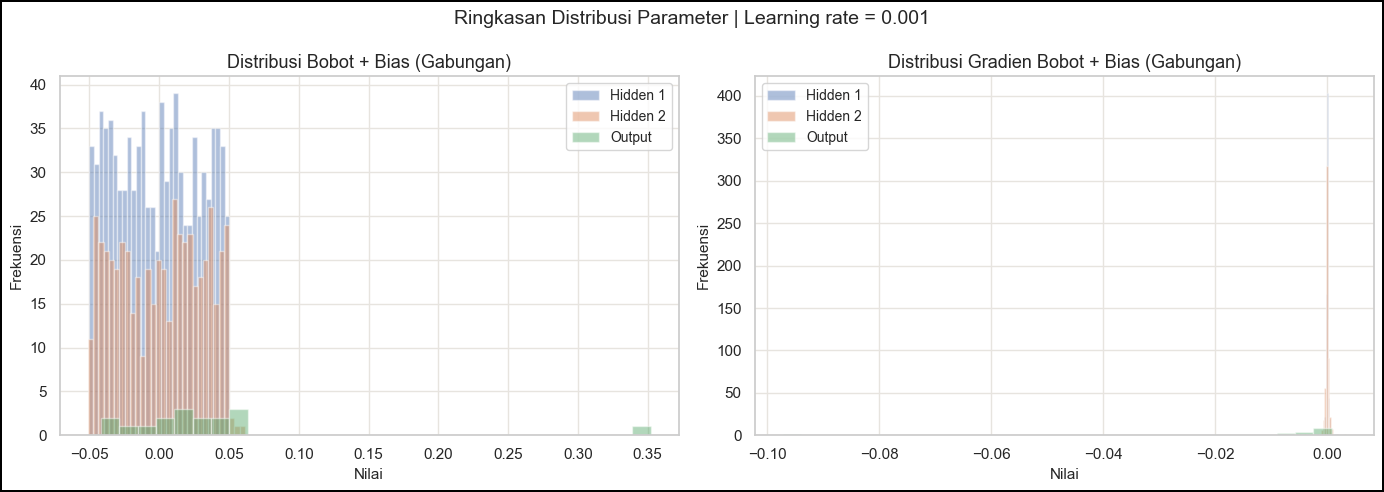

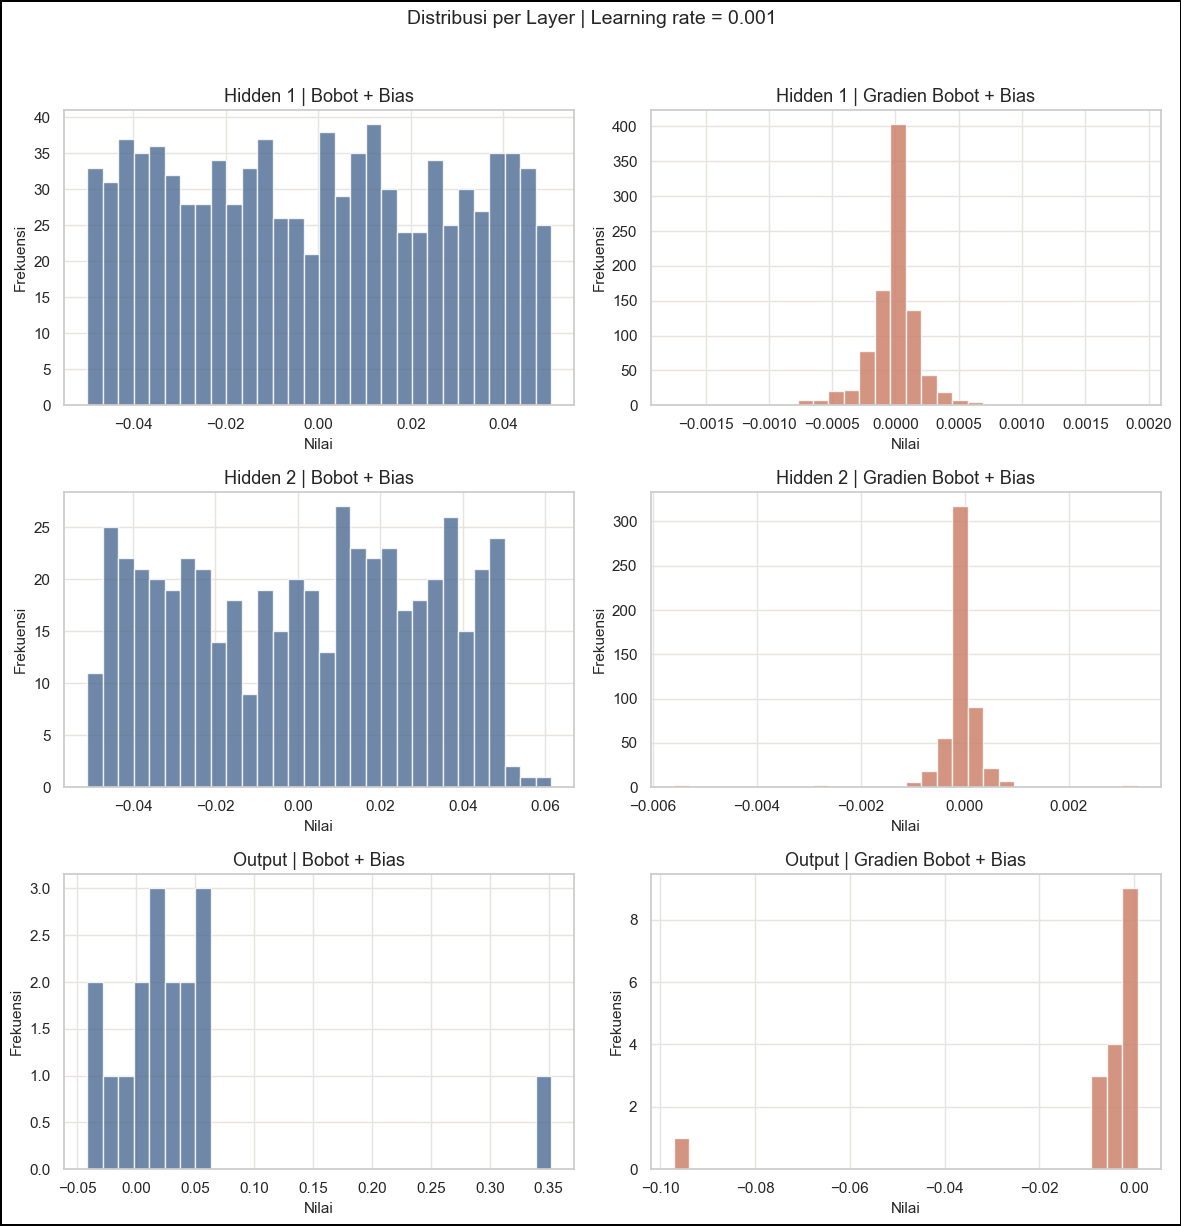

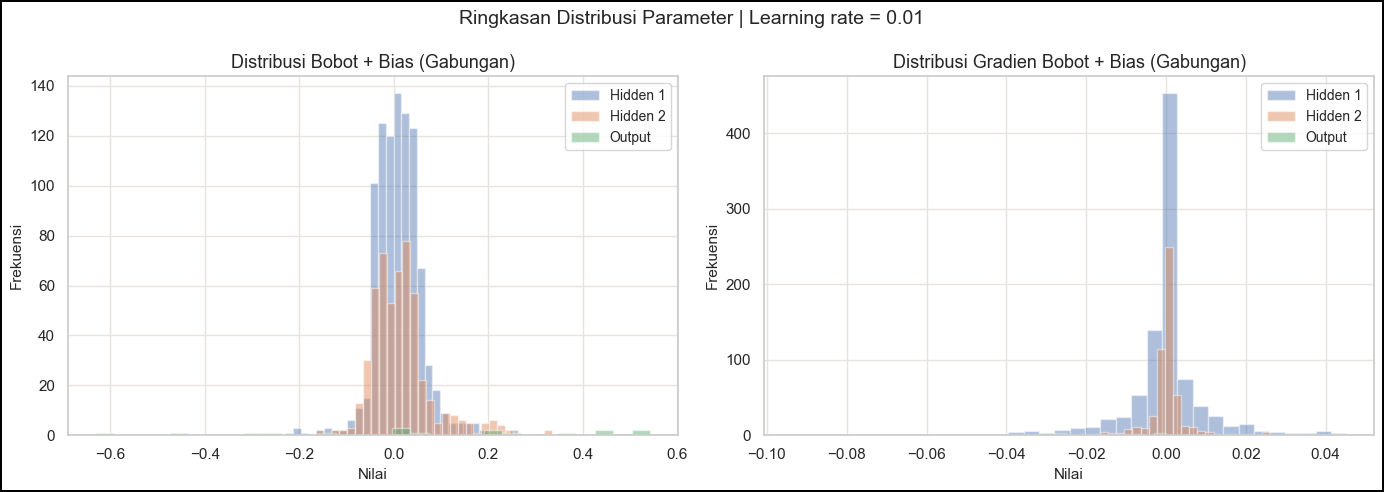

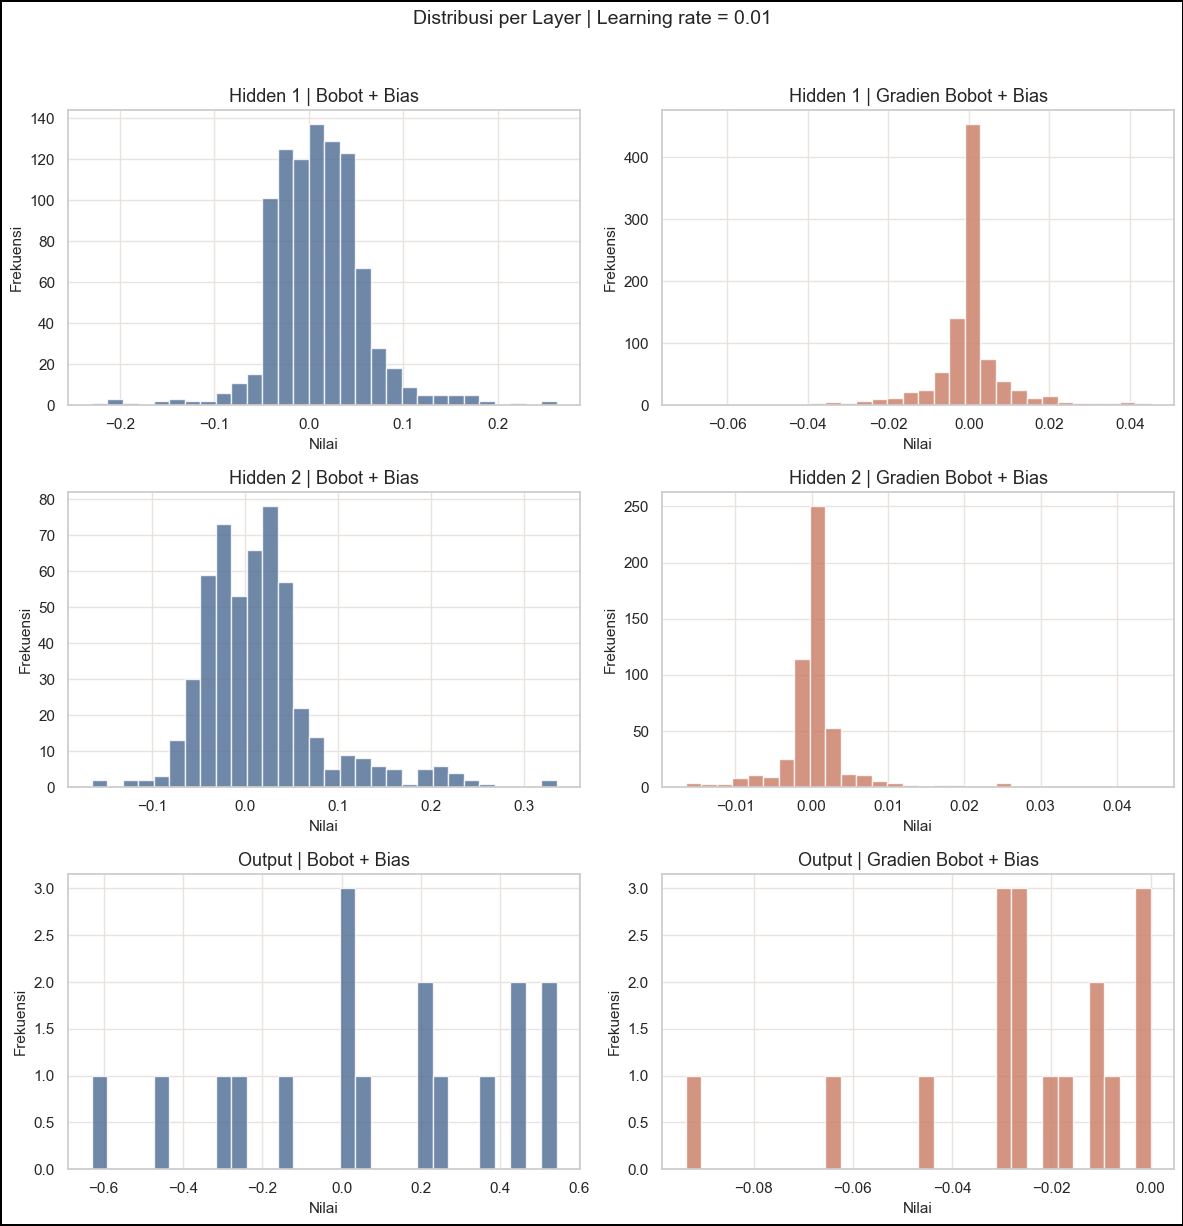

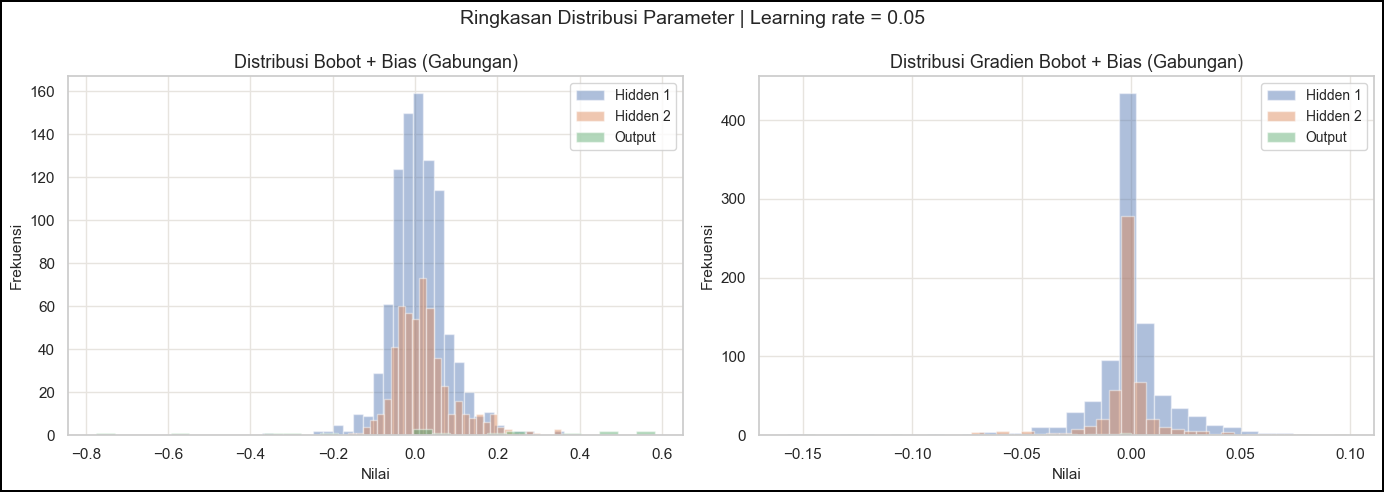

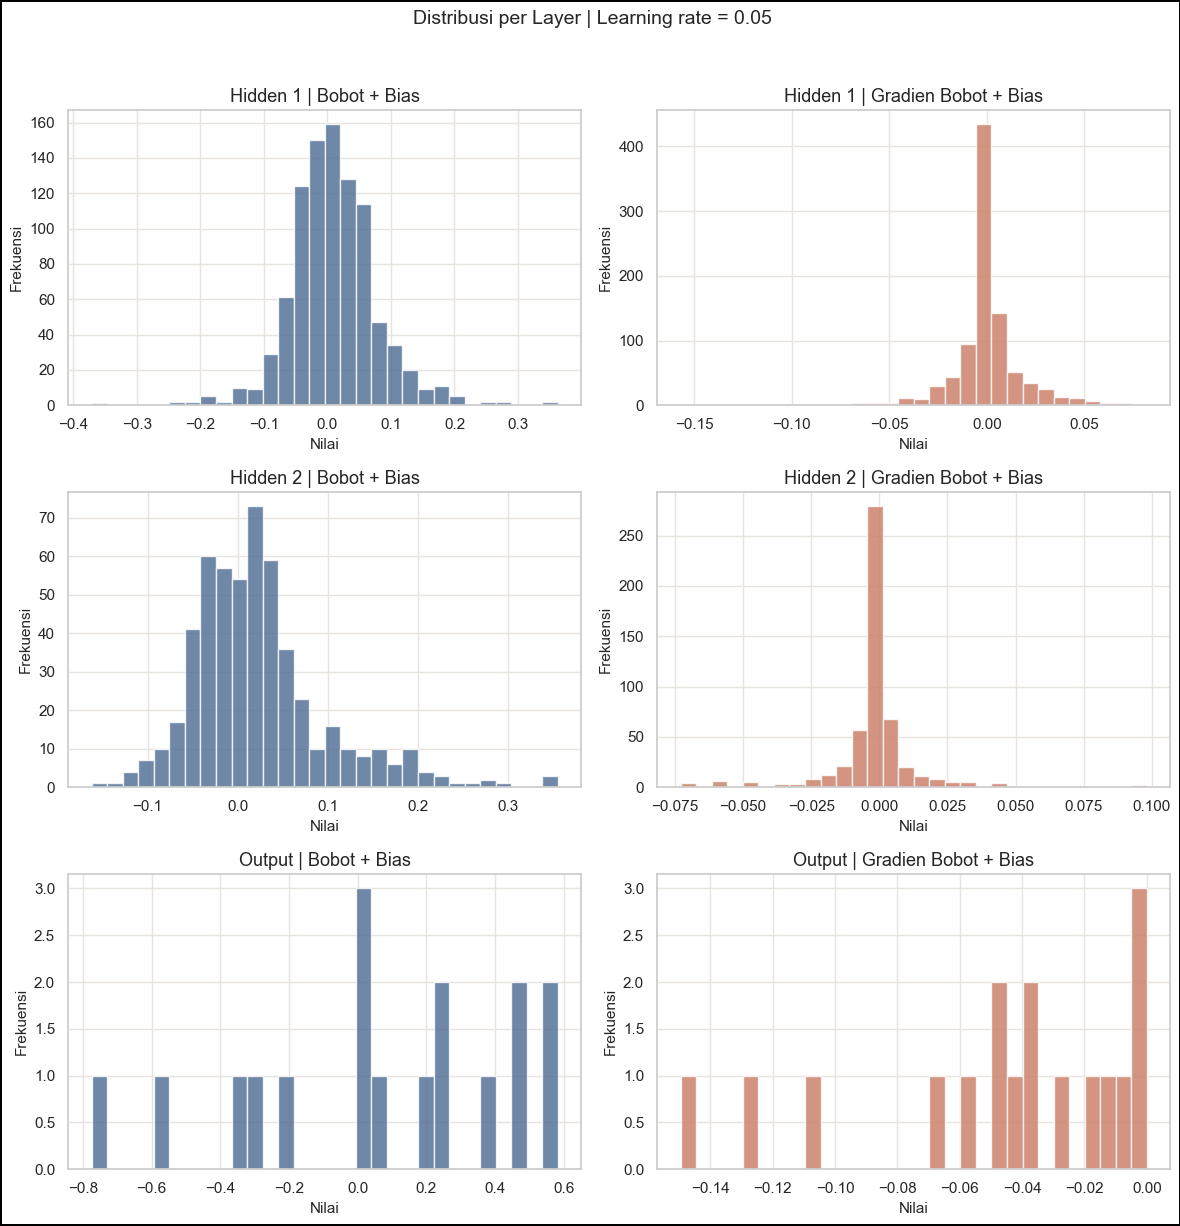

In [14]:
learning_rates = [0.001, 0.01, 0.05]
learning_rate_results = []

for lr in learning_rates:
    learning_rate_results.append(
        run_ffnn_experiment(
            name=f'Learning rate = {lr}',
            hidden_layers=BASE_WIDTH,
            hidden_activations=BASE_ACTIVATIONS,
            learning_rate=lr,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )
    )

print('Hasil akhir prediksi untuk variasi learning rate:')
display(to_metric_frame(learning_rate_results))
plot_loss_curves(learning_rate_results, 'Pengaruh Learning Rate')

for result in learning_rate_results:
    plot_parameter_overview(result['model'], result['name'])

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Analisis Regularisasi <a name="8"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Regularisasi dibandingkan pada tiga skenario: tanpa regularisasi, L1, dan L2. Nilai `lambda` dibuat sama pada dua skenario regularisasi agar pembandingan lebih langsung.

Hasil akhir prediksi untuk variasi regularisasi:


,Eksperimen,Accuracy,Precision,Recall,F1
0,Regularisasi L2,0.7520,0.784223,0.823721,0.803487
1,Tanpa regularisasi,0.7510,0.785214,0.819659,0.802067
2,Regularisasi L1,0.6155,0.615500,1.000000,0.761993


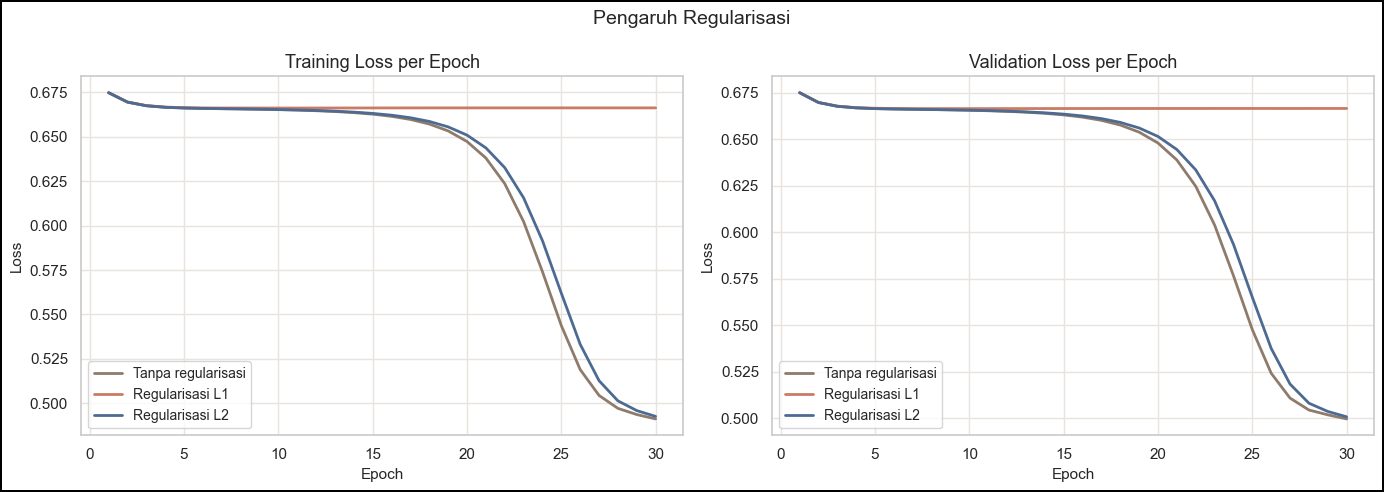

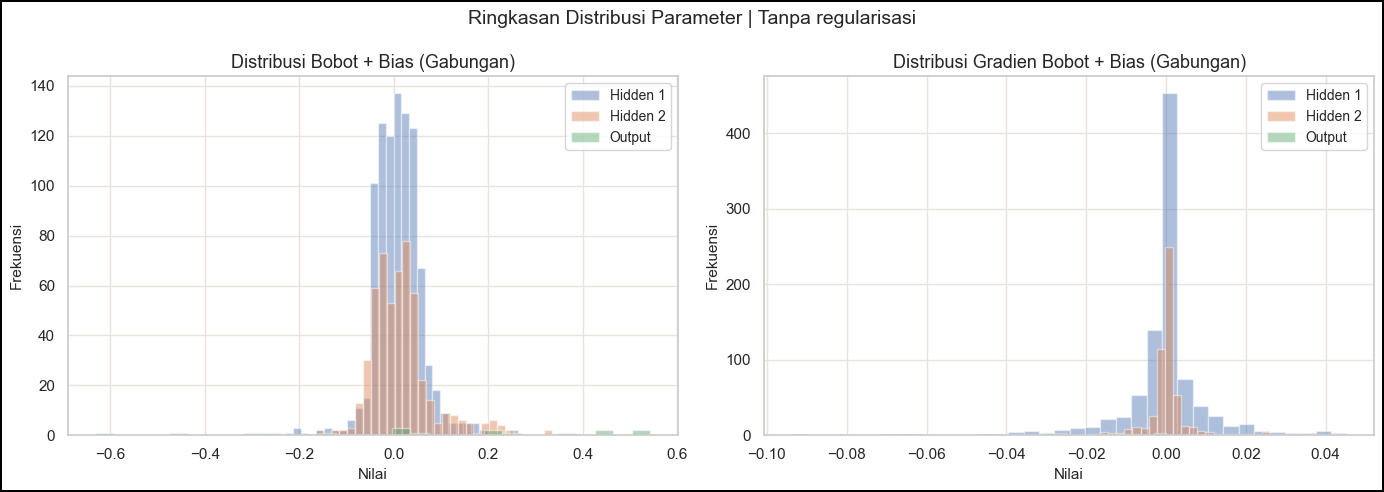

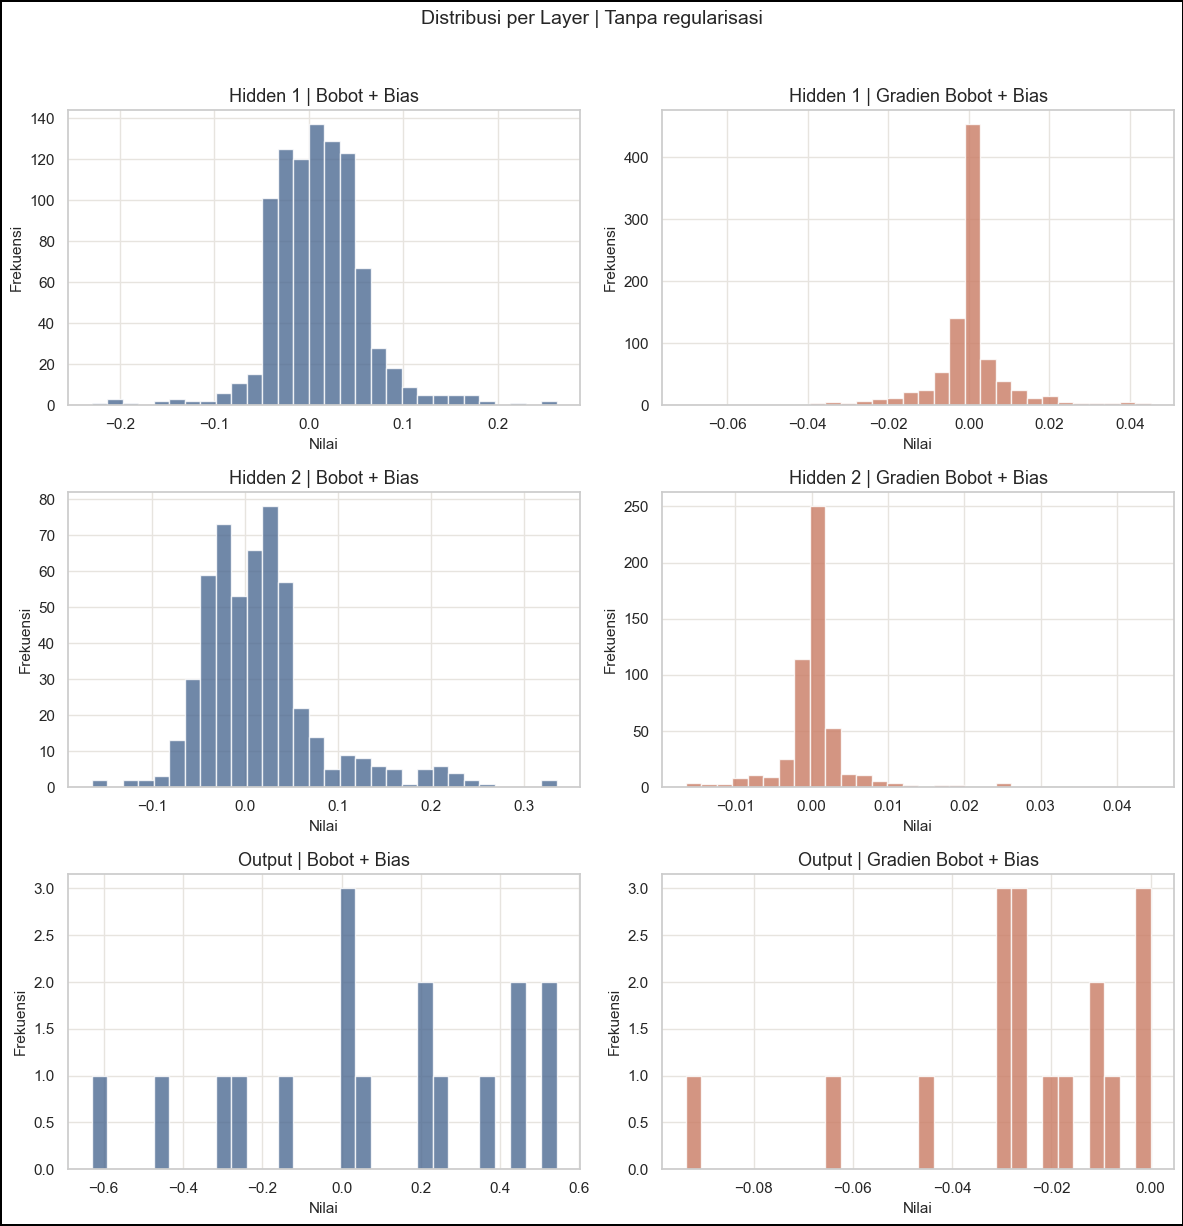

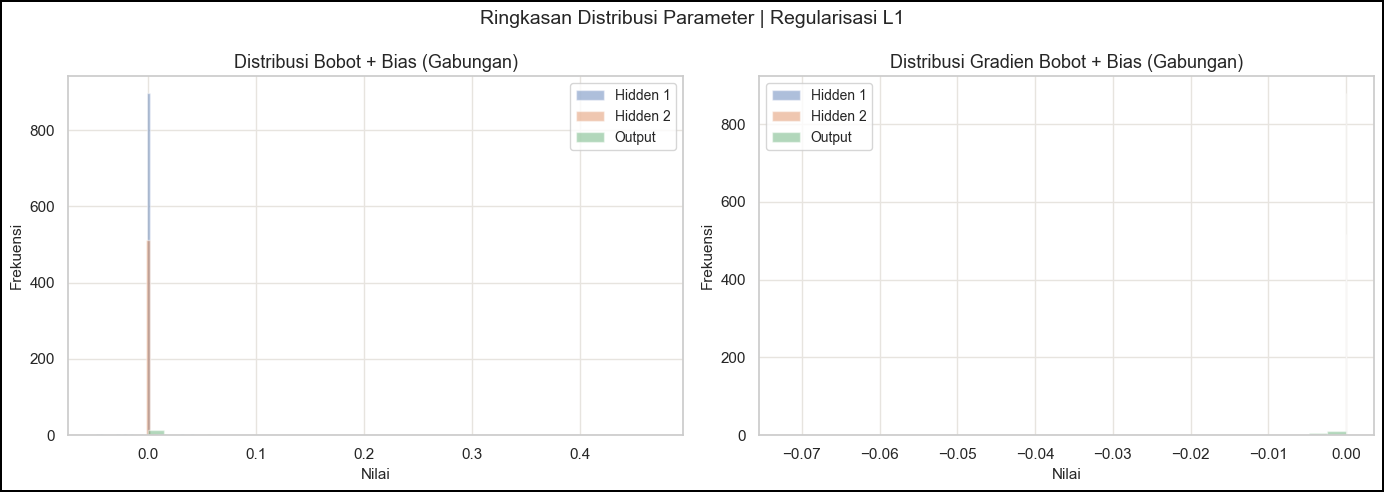

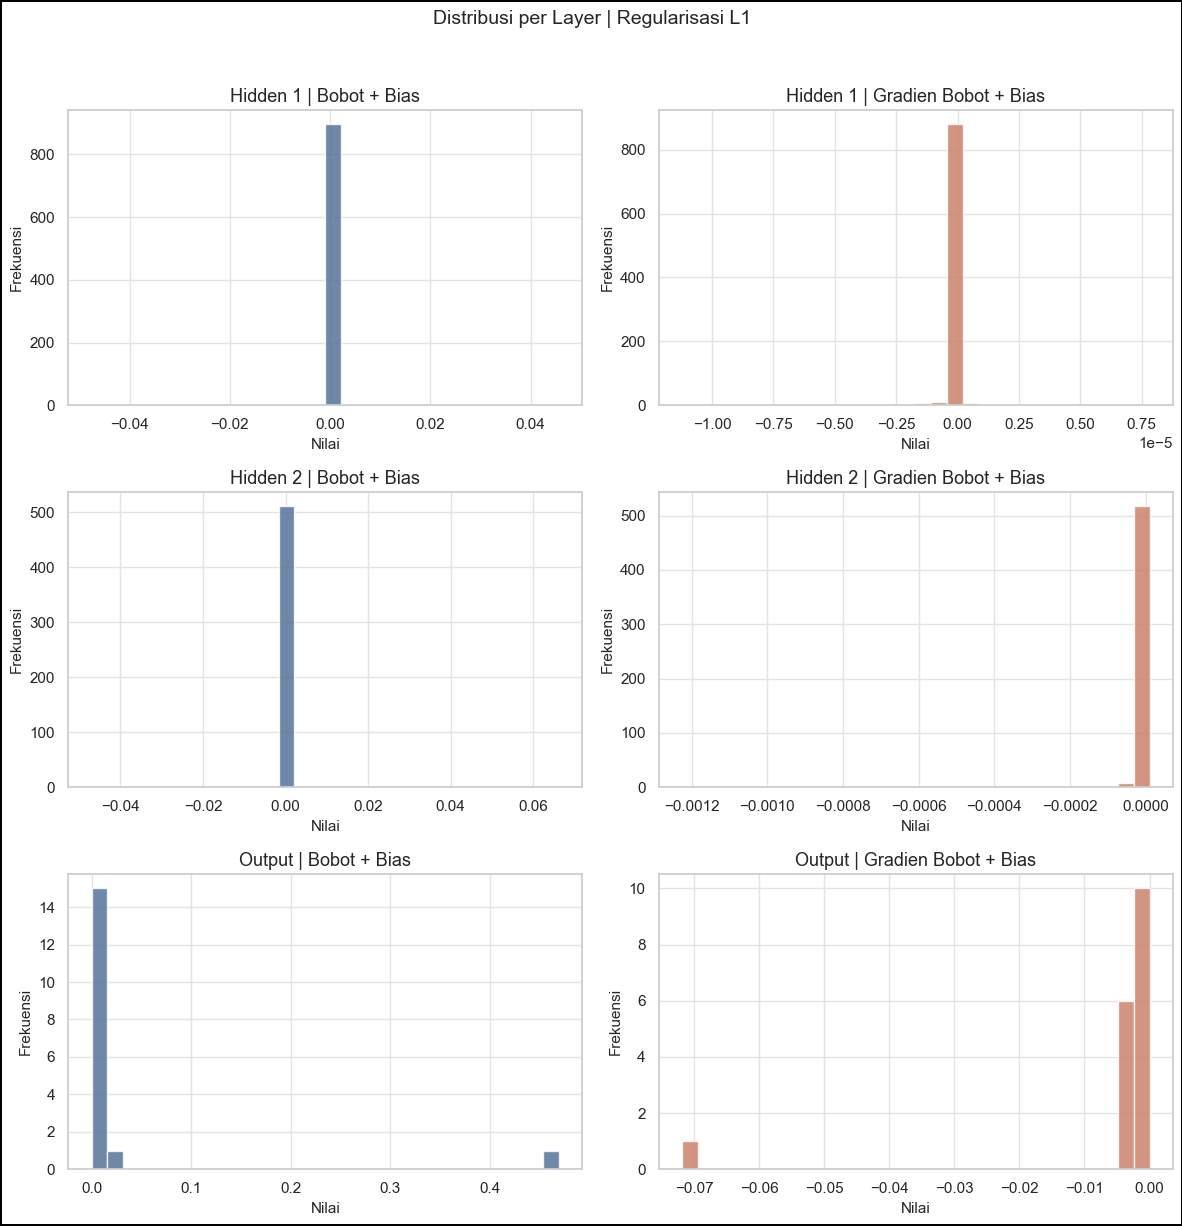

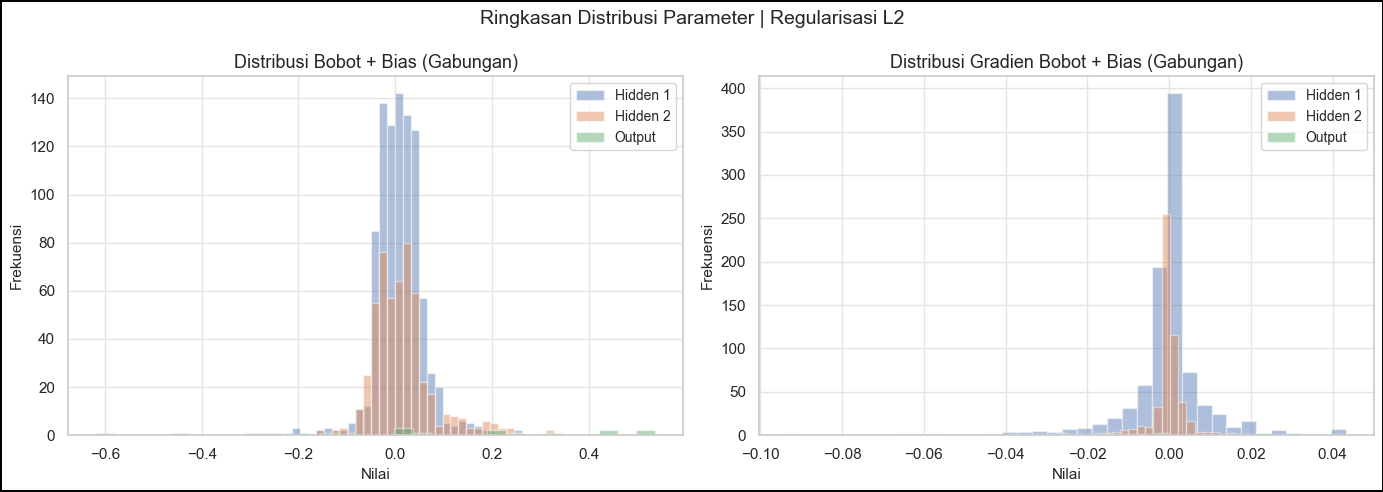

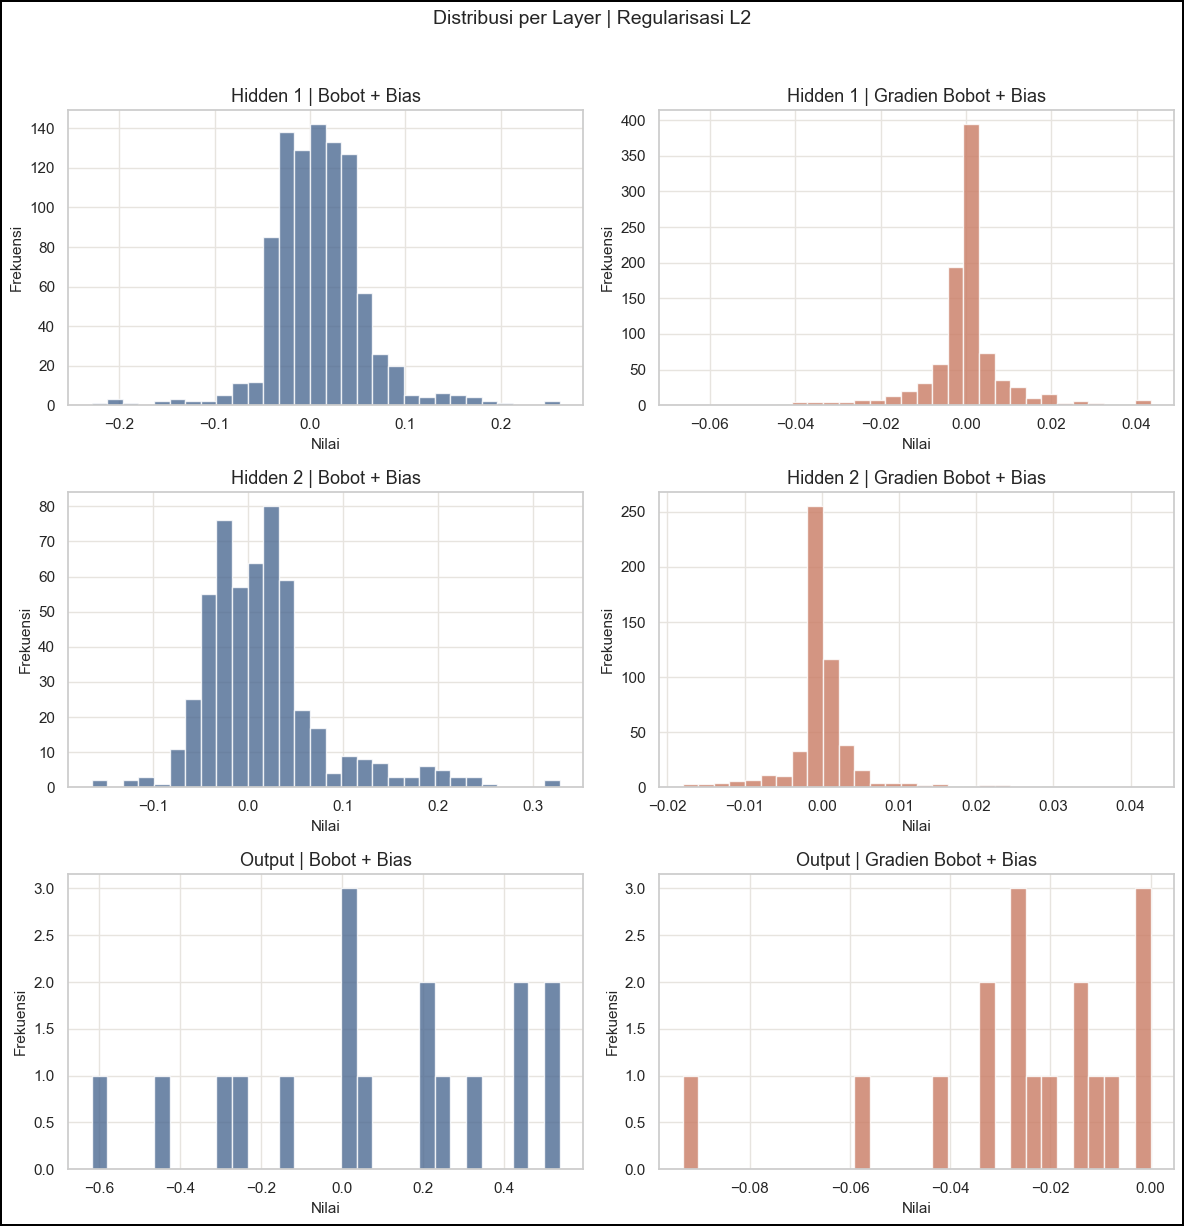

In [15]:
regularization_configs = [
    ('Tanpa regularisasi', None, 0.0),
    ('Regularisasi L1', 'l1', 0.001),
    ('Regularisasi L2', 'l2', 0.001)
]

regularization_results = []
for name, regularization_type, lam in regularization_configs:
    regularization_results.append(
        run_ffnn_experiment(
            name=name,
            hidden_layers=BASE_WIDTH,
            hidden_activations=BASE_ACTIVATIONS,
            learning_rate=BASE_LEARNING_RATE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            regularization_type=regularization_type,
            lam=lam,
            verbose=0
        )
    )

print('Hasil akhir prediksi untuk variasi regularisasi:')
display(to_metric_frame(regularization_results))
plot_loss_curves(regularization_results, 'Pengaruh Regularisasi')

for result in regularization_results:
    plot_parameter_overview(result['model'], result['name'])

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Perbandingan dengan sklearn MLP <a name="9"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Bagian ini melatih satu model FFNN dan satu `MLPClassifier` dari `sklearn` dengan hyperparameter yang dibuat sebanding: hidden layer, learning rate, jumlah epoch, dan batch size yang sama. Fokus pembandingan berada pada hasil akhir prediksi pada data uji.

In [18]:
ffnn_vs_sklearn = run_ffnn_experiment(
    name='FFNN scratch',
    hidden_layers=BASE_WIDTH,
    hidden_activations=BASE_ACTIVATIONS,
    learning_rate=BASE_LEARNING_RATE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

sklearn_vs_ffnn = run_sklearn_mlp(
    name='sklearn MLPClassifier',
    hidden_layers=BASE_WIDTH,
    activation='relu',
    learning_rate=BASE_LEARNING_RATE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

comparison_table = pd.DataFrame([
    {
        'Model': ffnn_vs_sklearn['name'],
        'Accuracy': ffnn_vs_sklearn['metrics']['accuracy'],
        'Precision': ffnn_vs_sklearn['metrics']['precision'],
        'Recall': ffnn_vs_sklearn['metrics']['recall'],
        'F1': ffnn_vs_sklearn['metrics']['f1']
    },
    {
        'Model': sklearn_vs_ffnn['name'],
        'Accuracy': sklearn_vs_ffnn['metrics']['accuracy'],
        'Precision': sklearn_vs_ffnn['metrics']['precision'],
        'Recall': sklearn_vs_ffnn['metrics']['recall'],
        'F1': sklearn_vs_ffnn['metrics']['f1']
    }
]).sort_values('F1', ascending=False).reset_index(drop=True)

print('Perbandingan hasil akhir prediksi FFNN vs sklearn MLP:')
display(comparison_table)

prediction_preview = pd.DataFrame({
    'Aktual': y_test.reshape(-1)[:15],
    'FFNN scratch': ffnn_vs_sklearn['predictions'][:15],
    'sklearn MLP': sklearn_vs_ffnn['predictions'][:15]
})

print('Contoh 15 prediksi pertama pada data uji:')
display(prediction_preview)

Training:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1/30 - loss: 0.6749 - val_loss: 0.6749
Epoch 2/30 - loss: 0.6696 - val_loss: 0.6697
Epoch 3/30 - loss: 0.6675 - val_loss: 0.6676
Epoch 4/30 - loss: 0.6666 - val_loss: 0.6668
Epoch 5/30 - loss: 0.6662 - val_loss: 0.6664
Epoch 6/30 - loss: 0.6660 - val_loss: 0.6662
Epoch 7/30 - loss: 0.6658 - val_loss: 0.6660
Epoch 8/30 - loss: 0.6657 - val_loss: 0.6659
Epoch 9/30 - loss: 0.6655 - val_loss: 0.6657
Epoch 10/30 - loss: 0.6653 - val_loss: 0.6655
Epoch 11/30 - loss: 0.6650 - val_loss: 0.6652
Epoch 12/30 - loss: 0.6647 - val_loss: 0.6649
Epoch 13/30 - loss: 0.6642 - val_loss: 0.6644
Epoch 14/30 - loss: 0.6636 - val_loss: 0.6638
Epoch 15/30 - loss: 0.6628 - val_loss: 0.6630
Epoch 16/30 - loss: 0.6615 - val_loss: 0.6618
Epoch 17/30 - loss: 0.6598 - val_loss: 0.6601
Epoch 18/30 - loss: 0.6572 - val_loss: 0.6575
Epoch 19/30 - loss: 0.6533 - val_loss: 0.6537
Epoch 20/30 - loss: 0.6474 - val_loss: 0.6479
Epoch 21/30 - loss: 0.6381 - val_loss: 0.6388
Epoch 22/30 - loss: 0.6236 - val_loss: 0.62

,Model,Accuracy,Precision,Recall,F1
0,sklearn MLPClassifier,0.7565,0.784404,0.833469,0.808192
1,FFNN scratch,0.7510,0.785214,0.819659,0.802067


Contoh 15 prediksi pertama pada data uji:


,Aktual,FFNN scratch,sklearn MLP
0,0,1,0
1,0,0,0
2,0,1,1
3,0,0,1
4,1,1,1
5,0,1,1
6,0,1,1
7,1,0,0
8,0,1,0
9,1,1,1


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Ringkasan Akhir <a name="10"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Bagian ini merangkum model terbaik dari setiap kelompok eksperimen. Ringkasan ini memudahkan pembacaan cepat sebelum masuk ke analisis visual yang lebih detail pada section sebelumnya.

In [19]:
summary_tables = [
    ('Width terbaik', to_metric_frame(width_results).head(1)),
    ('Depth terbaik', to_metric_frame(depth_results).head(1)),
    ('Aktivasi terbaik', to_metric_frame(activation_results).head(1)),
    ('Learning rate terbaik', to_metric_frame(learning_rate_results).head(1)),
    ('Regularisasi terbaik', to_metric_frame(regularization_results).head(1)),
    ('Perbandingan sklearn', comparison_table.head(1).rename(columns={'Model': 'Eksperimen'}))
]

summary_frames = []
for category, frame in summary_tables:
    current = frame.copy()
    current.insert(0, 'Kategori', category)
    summary_frames.append(current)

final_summary = pd.concat(summary_frames, ignore_index=True)
display(final_summary)

best_row = final_summary.sort_values('F1', ascending=False).iloc[0]
display(Markdown(
    f"**Model dengan F1 tertinggi pada seluruh notebook:** {best_row['Eksperimen']} "
    f"dari kategori **{best_row['Kategori']}** dengan nilai **{best_row['F1']:.4f}**."
))

,Kategori,Eksperimen,Accuracy,Precision,Recall,F1
0,Width terbaik,Width 32-16,0.7510,0.785214,0.819659,0.802067
1,Depth terbaik,Depth 2 hidden layer,0.7535,0.780395,0.834281,0.806439
2,Aktivasi terbaik,Hidden 1 = relu,0.7510,0.785214,0.819659,0.802067
3,Learning rate terbaik,Learning rate = 0.01,0.7510,0.785214,0.819659,0.802067
4,Regularisasi terbaik,Regularisasi L2,0.7520,0.784223,0.823721,0.803487
5,Perbandingan sklearn,sklearn MLPClassifier,0.7565,0.784404,0.833469,0.808192


**Model dengan F1 tertinggi pada seluruh notebook:** sklearn MLPClassifier dari kategori **Perbandingan sklearn** dengan nilai **0.8082**.